# **EDA**

In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

**Cargar el dataset**

In [8]:

ruta_externa = os.path.abspath("../Data")
df = pd.read_csv(f'{ruta_externa}/Data_Banreservas_Cleaned.csv')

print(df.shape)
df.head()

(18939, 16)


,Document ID,Date,Time,URL,Author Name,Author Handle,Hit Sentence,Hashtags,Keyphrases,Reach,Engagement,Likes,Replies,Reposts,Views,Cleaned_Text
0,"""1751342295000_SurW75nfLlvU0m3xEZMNhT1fWjwA""",2025-06-30,23:58,https://twitter.com/unstoppable8672/statuses/1...,Lobito,@unstoppable8672,"RT @EuricSanti: De los miles de registros, apa...",Sin_Hashtag,Ninguna,4957,0.0,0.0,0.0,0.0,0.0,rt de los miles de registros aparecen algunas ...
1,"""1751341139000_d46Z8XxSNcEaqgE5cfnSJuVWaHcA""",2025-06-30,23:38,https://twitter.com/Camilocuryv/statuses/19398...,Camilo Cury,@camilocuryv,Banreservas es del pueblo y como todo lo devor...,Sin_Hashtag,Ninguna,23,0.0,0.0,0.0,0.0,0.0,banreservas es del pueblo y como todo lo devor...
2,"""1751340275000_DS6Eat50RKdbBiQgefq0vlfULecA""",2025-06-30,23:24,https://twitter.com/feyesperanza03/statuses/19...,Gustavo A. Geronimo,@feyesperanza03,RT @bolivarvalera: Víctor Manuel Vargas Jiméne...,Sin_Hashtag,Ninguna,238,0.0,0.0,0.0,0.0,0.0,rt víctor manuel vargas jiménez banreservas cu...
3,"""1751340232000_gWlyJ3BPlQR60QdeoGqfpYiCYSgA""",2025-06-30,23:23,https://twitter.com/LuisitoPieTKD/statuses/193...,Luisito Pie,@luisitopietkd,RT @bolivarvalera: Víctor Manuel Vargas Jiméne...,Sin_Hashtag,Ninguna,5185,0.0,0.0,0.0,0.0,0.0,rt víctor manuel vargas jiménez banreservas cu...
4,"""1751337106000_t9aUW4L_-HE7rHUp5x-yIazQjCIA""",2025-06-30,22:31,https://twitter.com/CarlosIPineyroG/statuses/1...,CARLOS IVAN PIÑEYRO GALLARDO,@carlosipineyrog,Y que está pasando con banreservas que veo en ...,Sin_Hashtag,fraudes de consumos de tc;mismo banco;sres ojo...,40,0.0,0.0,0.0,0.0,0.0,y que está pasando con banreservas que veo en ...


**Estructura del** **dataset**

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18939 entries, 0 to 18938
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Document ID    18939 non-null  str    
 1   Date           18939 non-null  str    
 2   Time           18939 non-null  str    
 3   URL            18939 non-null  str    
 4   Author Name    18939 non-null  str    
 5   Author Handle  18939 non-null  str    
 6   Hit Sentence   18939 non-null  str    
 7   Hashtags       18939 non-null  str    
 8   Keyphrases     18939 non-null  str    
 9   Reach          18939 non-null  int64  
 10  Engagement     18939 non-null  float64
 11  Likes          18939 non-null  float64
 12  Replies        18939 non-null  float64
 13  Reposts        18939 non-null  float64
 14  Views          18939 non-null  float64
 15  Cleaned_Text   18939 non-null  str    
dtypes: float64(5), int64(1), str(10)
memory usage: 12.9 MB


**Valores faltantes**

In [10]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_percentage = (nulls / len(df)) * 100
print(nulls_percentage)

Document ID      0.0
Date             0.0
Time             0.0
URL              0.0
Author Name      0.0
Author Handle    0.0
Hit Sentence     0.0
Hashtags         0.0
Keyphrases       0.0
Reach            0.0
Engagement       0.0
Likes            0.0
Replies          0.0
Reposts          0.0
Views            0.0
Cleaned_Text     0.0
dtype: float64


**Variables numéricas**

In [11]:
df.describe()

,Reach,Engagement,Likes,Replies,Reposts,Views
count,1.893900e+04,18939.000000,18939.000000,18939.000000,18939.000000,1.893900e+04
mean,3.099002e+04,3.731084,2.368182,0.415545,0.743809,5.903571e+02
std,1.704116e+05,27.547294,17.025357,6.266858,6.166559,2.455067e+04
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2.230000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00
50%,7.700000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00
75%,3.226000e+03,0.000000,0.000000,0.000000,0.000000,0.000000e+00
max,1.836272e+06,1018.000000,545.000000,721.000000,367.000000,2.195323e+06


**Validación de fechas**

In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Fechas inválidas:", df['Date'].isnull().sum())

Fechas inválidas: 0


**Inspección de texto**

In [13]:
df['Hit Sentence'].sample(5)

9527     Cuenta Digital Banreservas https://t.co/8lKCsX...
4359     RT @AnaGarcia8756: Banreservas @BanreservasRD ...
17893    de entrega y dedicación. ¡Los felicito por est...
10218    Banreservas se consagra con la mayor cantidad ...
7964     confidencial, recuerda que nunca te contactare...
Name: Hit Sentence, dtype: str

**Duplicados**

In [14]:
print("Duplicados (excluyendo 'Document ID'):", df.drop(columns=['Document ID']).duplicated().sum())

Duplicados (excluyendo 'Document ID'): 0


**Relaciones básicas**

In [15]:
df[['Reach', 'Engagement', 'Likes']].describe()

,Reach,Engagement,Likes
count,1.893900e+04,18939.000000,18939.000000
mean,3.099002e+04,3.731084,2.368182
std,1.704116e+05,27.547294,17.025357
min,0.000000e+00,0.000000,0.000000
25%,2.230000e+02,0.000000,0.000000
50%,7.700000e+02,0.000000,0.000000
75%,3.226000e+03,0.000000,0.000000
max,1.836272e+06,1018.000000,545.000000


**Rango de Fechas del Dataset**

In [16]:
min_date = df['Date'].min()
max_date = df['Date'].max()

print(f"Fecha mínima: {min_date}")
print(f"Fecha máxima: {max_date}")

Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-12-31 00:00:00


## Análisis y Visualización de Variables Categóricas



**Métricas de engagement**

In [17]:
metricas = ['Reach', 'Engagement', 'Likes', 'Replies', 'Reposts', 'Views']

df[metricas].describe()

,Reach,Engagement,Likes,Replies,Reposts,Views
count,1.893900e+04,18939.000000,18939.000000,18939.000000,18939.000000,1.893900e+04
mean,3.099002e+04,3.731084,2.368182,0.415545,0.743809,5.903571e+02
std,1.704116e+05,27.547294,17.025357,6.266858,6.166559,2.455067e+04
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2.230000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00
50%,7.700000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00
75%,3.226000e+03,0.000000,0.000000,0.000000,0.000000,0.000000e+00
max,1.836272e+06,1018.000000,545.000000,721.000000,367.000000,2.195323e+06


**Distribución**

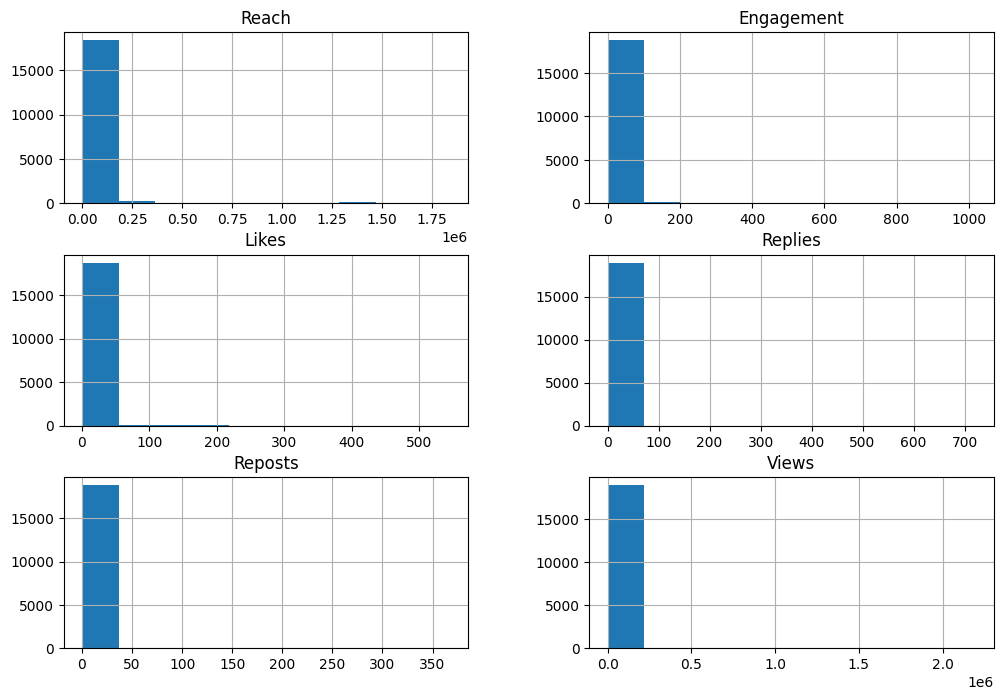

In [19]:
df[metricas].hist(figsize=(12,8))
plt.show()

**Top publicaciones**

In [20]:
top_posts = df.sort_values(by='Engagement', ascending=False).head(10)

top_posts[['Author Name', 'Cleaned_Text', 'Engagement']]

,Author Name,Cleaned_Text,Engagement
6822,Misael Guzmán 🇩🇴,envíenle a su primo misael sus cuentas del ban...,1018.0
4199,Somos Pueblo Media,supera los tres millones de pesos una suma que...,898.0
11890,Felipe Gavilán,alarmante noticia de ultima hora varias person...,790.0
13522,🅳🅾🅼🅸🅽🅸🅲🅰🅽🅰🅼🅴🅽🆃🅴,se fue a pique banreservas en saicedo,769.0
16599,Luis Abinader,queda designado el dr leonardo aguilera como n...,753.0
5307,Somos Pueblo Media,bancarias para recibir donaciones y facilitar ...,726.0
11084,Atttenea,empecemos por cancelar las tarjetas del banres...,683.0
3047,Samuel Pereyra Rojas,hoy es un gran día para banreservas nuestro de...,603.0
11343,Euric Santi 🧎🏽‍♂️,estoy diciendo desde hace tiempo problemas en ...,575.0
3668,José Peguero,alerta de fraude a clientes del banco de reser...,512.0


**Top autores por engagement**

In [21]:
# Agrupar por autor y sumar el engagement total
top_autores = df.groupby('Author Name')['Engagement'].sum()

# Ordenar de mayor a menor
top_autores = top_autores.sort_values(ascending=False).head(10)

# Mostrar resultados
print(top_autores)

Author Name
Samuel Pereyra Rojas                              10839.0
Somos Pueblo Media                                 2261.0
𝗡𝗼𝘁𝗶d𝗶𝗴𝗶𝘁𝗮𝗹rd.c𝗼𝗺.do                               2206.0
Héctor Gómez                                       1925.0
Ministerio Educación RD                            1867.0
Misael Guzmán 🇩🇴                                   1624.0
Euric Santi 🧎🏽‍♂️                                  1487.0
Felipe Gavilán                                     1285.0
José Marte                                         1269.0
Cámara de Diputados de la República Dominicana     1241.0
Name: Engagement, dtype: float64


**Hashtags más usados**

In [22]:
hashtags = df['Hashtags'].astype(str).str.split().explode()

top_hashtags = hashtags.value_counts().head(10)

print(top_hashtags)

Hashtags
Sin_Hashtag                                                    11931
#banreservas                                                     504
#diputadosrd                                                     189
#banreservas;#elbancodetodoslosdominicanos                       160
#elpregonerord                                                   139
#banreservas;#guiadebeneficiosbr;#ofertapuntual;#tarjetasbr      116
#gabinetela                                                       96
#eldemocratard                                                    87
#ayúdameallegarabarcelona;#ayúdameasanar                          78
#banreservas;#fuerzadelpueblo                                     69
Name: count, dtype: int64


**Correlación entre métricas**

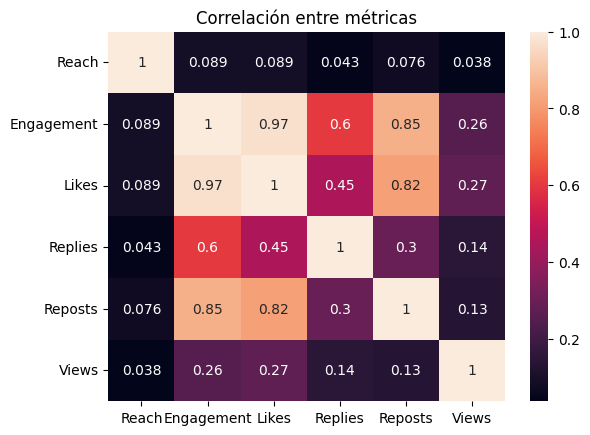

In [ ]:
corr = df[metricas].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlación entre métricas")
plt.show()

## Resumen de Hallazgos

**1. Estructura del Dataset:**
*   El dataset contiene `18,939` filas y `17` columnas.
*   Las columnas incluyen una mezcla de tipos de datos: `object` (para IDs, texto, nombres, etc.), `datetime64[ns]` para la columna `Date`, y `int64` para las métricas numéricas como `Reach` y `Engagement`.
*   Las columnas clave para el análisis de contenido son `Hit Sentence`, `Hashtags`, `Sentiment`, `Keyphrases`, y `Cleaned_Text`.

**2. Valores Faltantes:**
*   No se encontraron valores faltantes en ninguna de las columnas del dataset, lo que indica un dataset limpio en este aspecto.

**3. Estadísticas Descriptivas (Variables Numéricas):**
*   Las métricas de interacción (`Reach`, `Engagement`, `Likes`, `Replies`, `Reposts`, `Views`) muestran una alta asimetría positiva.
*   La mayoría de las publicaciones tienen `0` interacciones (Likes, Replies, Reposts, Views) en el 75º percentil, indicando que solo un pequeño subconjunto de publicaciones logra una interacción significativa.
*   `Reach` tiene un promedio de `30,990` pero un valor máximo de `1.8 millones`, con una desviación estándar muy alta (`170,411`), lo que indica una gran variabilidad y la presencia de outliers.
*   `Engagement` tiene un promedio de `3.73` con un máximo de `1,018`.

**4. Métricas de Engagement:**
*   Los histogramas para todas las métricas de engagement (Reach, Engagement, Likes, Replies, Reposts, Views) confirman la fuerte asimetría positiva, con la mayoría de los valores concentrados en cero o valores muy bajos.
*   Esto sugiere que la mayoría de las publicaciones tienen poco o ningún engagement, mientras que unas pocas publicaciones reciben una atención desproporcionadamente alta.

**5. Hashtags Más Usados:**
*   El hashtag más frecuente, `Sin_Hashtag`, aparece `11,931` veces, lo que indica que una gran parte de las publicaciones no utiliza hashtags específicos o los utiliza de manera inconsistente.
*   El hashtag real más usado es `#banreservas` con `504` menciones, seguido por `#diputadosrd` (`189`) y `#banreservas;#elbancodetodoslosdominicanos` (`160`).
*   También se observan hashtags compuestos que combinan múltiples palabras clave.

**6. Correlación entre Métricas:**
*   Existe una correlación muy fuerte y positiva entre `Engagement`, `Likes` y `Reposts` (cercana a `0.97` entre Engagement y Likes, y `0.85` entre Engagement y Reposts). Esto sugiere que estas métricas se mueven en conjunto, y que una publicación con muchos likes probablemente también tendrá muchos reposts y alto engagement general.
*   `Replies` también muestra una correlación positiva fuerte con `Engagement` (`0.60`) y `Likes` (`0.45`).
*   `Reach` y `Views` tienen correlaciones más bajas con las métricas de interacción directa (Likes, Replies, Reposts, Engagement), lo que implica que una alta visibilidad no siempre se traduce en una alta interacción.

**7. Distribución Temporal de Publicaciones (Análisis por Hora):**
*   El gráfico de barras de publicaciones por hora muestra un patrón claro de actividad a lo largo del día.
*   Hay baja actividad durante las horas de la madrugada (aproximadamente de 0:00 a 6:00).
*   La actividad comienza a aumentar a partir de las 7:00-8:00 de la mañana.
*   Se observan picos de publicaciones alrededor del mediodía y, más notablemente, a media tarde/principios de la noche (aproximadamente de 16:00 a 19:00).
*   El número de publicaciones disminuye gradualmente después de las 20:00.